# Cat vs Dog CNN Model
## Dataset Overview
- Training Images: 8,005
- Testing Images: 2,023
- Classes:
 - Cats = 0
 - Dogs = 1
## Model Performance
- Test Accuracy: 80.82%
- Test Loss: 0.4462

This means the model correctly classifies approximately 81 out of every 100 images. This is a good result for a basic CNN model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Step 2 : Data Preprocessing

train_gen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip=True
)

# Testing data generator
test_gen = ImageDataGenerator(
    rescale=1./255
)

In [3]:
# Dataset paths

train_path = r"C:\Users\moham\Downloads\training_set"
test_path = r"C:\Users\moham\Downloads\test_set"

In [4]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [5]:
test_path =  r"C:\Users\moham\Downloads\test_set"

In [6]:
test_data = test_gen.flow_from_directory(
    test_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [7]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

C:\Users\moham\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model Summary
- The CNN model has 8 layers: Conv2D, MaxPooling, Flatten, Dense, Dropout, and Output layer.
- The model has 7,392,449 total parameters, all are trainable.
- The first Conv2D layer learns basic image features like edges and colors.
- MaxPooling layers reduce image size and keep important features.
- Flatten converts image features into a 1D format for classification.
- The Dense layer has the highest parameters, so most learning happens there.
- Dropout helps reduce overfitting.
- Final Dense layer has 1 neuron with sigmoid, so it predicts Cat or Dog.

In [10]:
# Step 6 : Early Stopping

es = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

In [11]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    callbacks=[es]
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 327ms/step - accuracy: 0.5352 - loss: 0.7068 - val_accuracy: 0.6471 - val_loss: 0.6654
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 300ms/step - accuracy: 0.6346 - loss: 0.6492 - val_accuracy: 0.6653 - val_loss: 0.6313
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 329ms/step - accuracy: 0.6610 - loss: 0.6230 - val_accuracy: 0.6980 - val_loss: 0.5962
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 94s 375ms/step - accuracy: 0.6938 - loss: 0.5914 - val_accuracy: 0.7064 - val_loss: 0.5828
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 106s 421ms/step - accuracy: 0.7047 - loss: 0.5696 - val_accuracy: 0.7133 - val_loss: 0.5776
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 104s 415ms/step - accuracy: 0.7280 - loss: 0.5483 - val_accuracy: 0.7469 - val_loss: 0.5308
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 111s 443ms/step - accuracy: 0.7432 - loss: 0.5252 - val_accuracy: 0.7573 - val_loss: 0.5114
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 113s 450ms/step - accuracy: 0.7503 - los

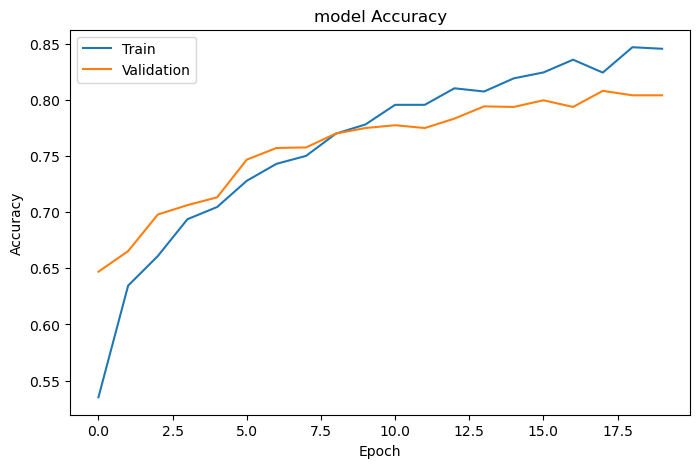

In [13]:
# Step 7 : Accuracy Graph

plt.figure(figsize =(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

## Accuracy Graph
- Training accuracy increased from 53.7% to 84.6%, showing the model learned important image features over time.
- Validation accuracy improved from 64.7% to 80.4%, indicating good performance on unseen images.
- Both training and validation accuracy curves rise steadily, which suggests effective learning.
- The gap between training accuracy (84.6%) and validation accuracy (80.4%) is small (~4%), indicating minimal overfitting.
- Validation accuracy becomes stable after around Epoch 14–15, meaning the model has largely converged.
- Data augmentation and dropout helped improve generalization and prevent overfitting.
- The final validation accuracy of 80%+ shows the CNN model can reliably classify cats and dogs.

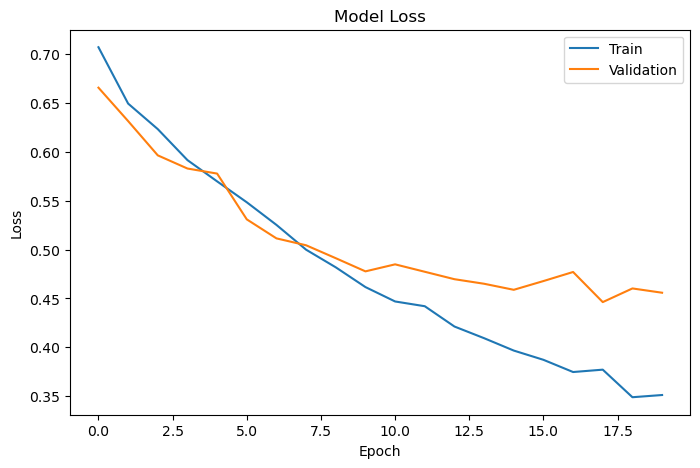

In [14]:
# Step 8 : Loss Graph

plt.figure(figsize= (8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

## Loss Graph Insights
- Training loss decreased from 0.70 to 0.35, showing the model learned effectively during training.
- Validation loss decreased from 0.66 to 0.45, indicating improved performance on unseen data.
- Both curves show a downward trend, which means the model is successfully minimizing prediction errors.
- The validation loss remains slightly higher than the training loss, which is expected in real-world models.
- There is only a small gap between training and validation loss, indicating minimal overfitting.
- Around Epoch 14–16, validation loss becomes stable, suggesting the model has reached optimal learning.
- The final loss values indicate that the CNN model generalizes well to new cat and dog images.

In [15]:
# Step 9 : Evaluate Model

loss,acc=model.evaluate(test_data)

print("Accuracy",acc)
print("Loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8082 - loss: 0.4462
Accuracy 0.8082056641578674
Loss 0.4462476670742035


In [16]:
# Step 10 : Save Model

model.save("cat_dog_cnn.h5")
print("Model saved successfully!")

Model saved successfully!


In [17]:
# Step 11 : Load Model

model = load_model("cat_dog_cnn.h5")

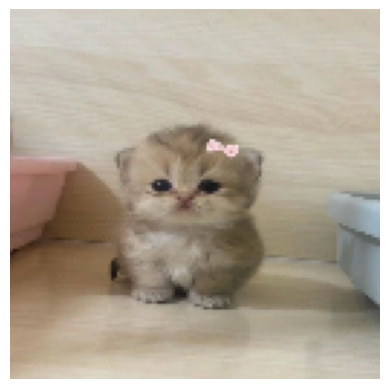

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
Prediction Score : 0.2831762


In [18]:
# Step 12 : Predict New Image

img_path = r"C:\Users\moham\Downloads\the cuty one_.🥹🥹 aawwwww.🥹🥹 aawwwww.🥹🥹 aawwwww"

img = image.load_img(
    img_path,
    target_size= (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis= 0)

pred = model.predict(img_arr)

print("Prediction Score :" , pred[0][0])

In [19]:
# Step 13 : Final Prediction

if pred[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

Cat


In [21]:
pip install pillow-avif-plugin

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.0 MB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.9 MB 1.3 MB/s eta 0:00:07
   -------------- ------------------------- 3.7/9.9 MB 5.0 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 7.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


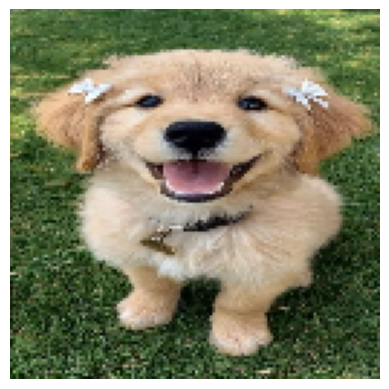

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Prediction Score: 0.998434
Dog


In [24]:
import pillow_avif
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model ("cat_dog_cnn.h5")
img_path = r"C:\Users\moham\Downloads\cute dog🐾.jpg"

img = image.load_img(img_path, target_size = (128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis = 0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

if pred [0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

## Conclusion

The Cat vs Dog Classification project successfully used a CNN model to classify images with an accuracy of 80.8%. The model effectively learned image features through convolution and pooling layers, demonstrating the potential of deep learning for image classification tasks.